# Introduction

Although major advances have been made in the treatment of HIV/AIDS, predicting which patients will respond successfully to therapy remains an important challenge. In this analysis, we will explore machine learning techniques to investigate how well treatment outcomes can be predicted using patient information collected during the ACTG 175 clinical trial. Our main research questions will be

1.   What are some important predictors for whether HIV treatment fails?
2.   What is the best model to predict whether HIV treatment fails in terms of the accuracy and true positive rate?




# Codebook

As an introduction to the data, it features 2139 observations with 1 target variable and 23 input variables. The target variable cid has two classes making this a binary classifcation problem. The column names are as follows:

**pidnum** (ID) - Patient ID

**cid** (Target) - Censoring indicator (1 = failure, 0 = censored) Failure means treatment was not effective/worsening of condition/death while censored means lack of evidence for condition worsening by end of study/patient surviving

**trt**	(Int)->(Cat) - treatment indicator (0 = ZDV only; 1 = ZDV + ddI, 2 = ZDV + Zal, 3 = ddI only)

**time** (Int) - Time to failure/censoring in days

**age** (Int) - Age of patient

**wtkg** (Cont) - Weight in kg of patient

**hemo** (Int) - Binary Indicator of Hemophilia (0=no, 1=yes)

**lgbtq** (Int) - Binary Indicator of LGBTQ activity (0=no, 1=yes)

**drugs** (Int) - history of IV drug use (0=no, 1=yes)

**karnof**	(Int)	- Karnofsky score (on a scale of 0-100) Indicating health with 100 as healthiest

**oprior** (Int) - Received Non-ZDV antiretroviral therapy pre-study (0=no, 1=yes)

**z30** (Int) - Received ZDV in the 30 days prior to study (0=no, 1=yes)

**zprior** (Int) - Received	ZDV prior to study (0=no, 1=yes)

**preanti** (Int) - # days on anti-retroviral therapy pre-study

**race** (Int) - race (0=White, 1=non-white)

**gender** (Int) - gender (0=F, 1=M)

**str2** (Int) - antiretroviral history (0=naive, 1=experienced)

**strat** (Int) - antiretroviral history stratification (1='Antiretroviral Naive',2='> 1 but $\leq$ 52 weeks of prior antiretroviral therapy',3='> 52 weeks)

**symptom** (Int) - symptomatic indicator (0=asymp, 1=symp)

**treat** (Int) - treatment indicator (0=ZDV only, 1=others)

**offtrt** (Int) - indicator of off-trt before 96+/-5 weeks (0=no,1=yes)

**cd40**	(Int)	-	CD4 at baseline

**cd420**	(Int)	-	CD4 at 20+/-5 weeks

**cd80**	(Int)	-	CD8 at baseline

**cd820**	(Int) -	CD8 at 20+/-5 weeks

Further documentation can be found at the UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/890/aids+clinical+trials+group+study+175

The data has no missing values but there are a few things regarding the categorical variables. str2 is a redundant version of strat as it combines 2 and 3 into one level experienced. treat is also a redundant version of trt that combines levels 2,3, and 4 into others. Thus we may consider dropping these variables. Furthermore trt is encoded as an integer when we should treat this as categorical as treatment groups are categories. We can approach this with dummy variables or one-hot enconding. Otherwise, the rest have been properly enconded as categorical variables. Note also that strat has been properly encoded as it is an ordinal variable. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [2]:
aids_clinical_trials_group_study_175 = fetch_ucirepo(id=890)
X = aids_clinical_trials_group_study_175.data.features
X.rename(columns = {'homo':'lgbtq'}, inplace = True)
y = aids_clinical_trials_group_study_175.data.targets.squeeze()

/var/folders/py/yn4jz9f166sd76n0j33k5ny00000gn/T/ipykernel_29790/1751369059.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.rename(columns = {'homo':'lgbtq'}, inplace = True)


# Exploratory Data Analysis

Before we begin modeling, we should look for any underlying patterns within the data. We can do this in the form of visualizations, contigency tables, and etc. Since we have so many features, we'll focus on the ones that tell a story.

Our first table looks at the proportions of the target variable. Notice how there is a class imbalance with 75.6% in the censored group and 23.4% in the failure group. This imbalance could be a problem for our models which we should address later.

In [69]:
y.value_counts(normalize = True)

cid
0    0.756428
1    0.243572
Name: proportion, dtype: float64

In [70]:
X.zprior.value_counts()

zprior
1    2139
Name: count, dtype: int64

Upon closer inspection, zprior only has 1 level that means it provides zero information to differentiate the observations and should be dropped.

For our first contingency table comparing treatment and cid, we can see that treatment group 0 (ZDV only) has the highest failure rate at 34% out of all treatments compared to the other treatments which were close to roughly 20%.

In [71]:
pd.crosstab(X.trt,y, normalize = "index")

cid,0,1
trt,,
0,0.659774,0.340226
1,0.802682,0.197318
2,0.791985,0.208015
3,0.771836,0.228164


Another contifency table comparing strat and cid showed that those who received prior antiretroviral treatment for longer periods of time had a higher failure rate. (Reminder 1='Antiretroviral Naive',2='> 1 but <= 52 weeks of prior antiretroviral therapy',3='> 52 weeks)

In [72]:
pd.crosstab(X.strat,y, normalize = "index")

cid,0,1
strat,,
1,0.819413,0.180587
2,0.748780,0.251220
3,0.693950,0.306050


Furthermore, those who received ZDV treatment within 30 days prior to the study had a higher failure rate at 29% compared to 18% for those who didn't.

In [73]:
pd.crosstab(X.z30,y, normalize = "index")

cid,0,1
z30,,
0,0.816008,0.183992
1,0.707732,0.292268


Moving onto boxplots, before the study began, CD4 measurements (type of white blood cell) were taken. Comparing the failure group to the censored group, we can see that the failure group has a an overall lower CD4 count as evidenced by the lower median and quartiles. 

[Text(0.5, 1.0, 'Boxplots for CD4 Count Between CID Groups Before Study')]

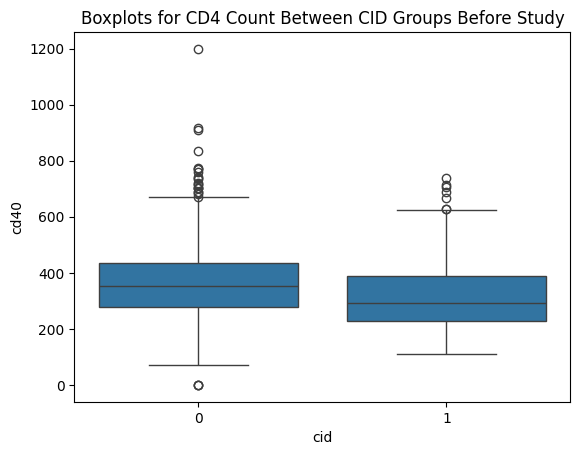

In [74]:
fig, ax = plt.subplots()
sns.boxplot(x = y, y = X.cd40, ax = ax)
ax.set(title = "Boxplots for CD4 Count Between CID Groups Before Study")

Here are the density plots for comparison. Both cid groups have a roughly right skewed distribution for CD4 counts.

[Text(0.5, 1.0, 'Density Plots for CD4 Count Between CID Groups Before Study')]

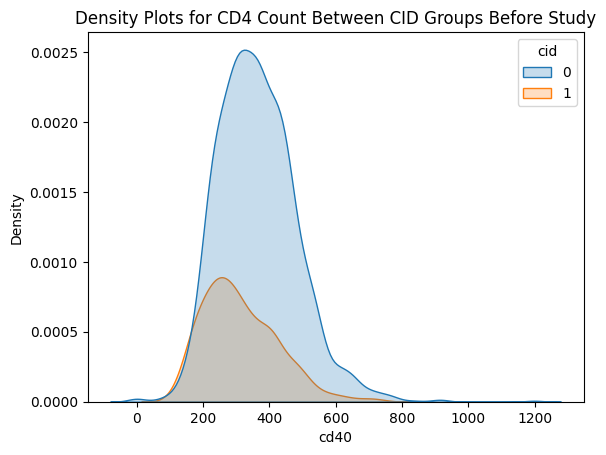

In [75]:
fig, ax = plt.subplots()
sns.kdeplot(x = X.cd40, hue = y, fill = True)
ax.set(title = "Density Plots for CD4 Count Between CID Groups Before Study")

A variable that's drastically different between cid groups would be time. Time is a measurement for how many days it took for failure to occur for the patient (cid = 1) or how many days the patient was event-free/condition not worsening (cid = 0). It showed that the censored group had a much higher median for time/days of being event free while failure happened much earlier for the failure group with a comparatively lower median. Also, It seems that there's a lot of outliers for the censored group as most observations tend to be within roughly 800-1200 days. An explanation for this would be that some participants dropped out earlier than expected, but because no events occured, they are still counted as censored.

[Text(0, 0.5, 'Days'), Text(0.5, 1.0, 'Boxplots for Time Between CID Groups')]

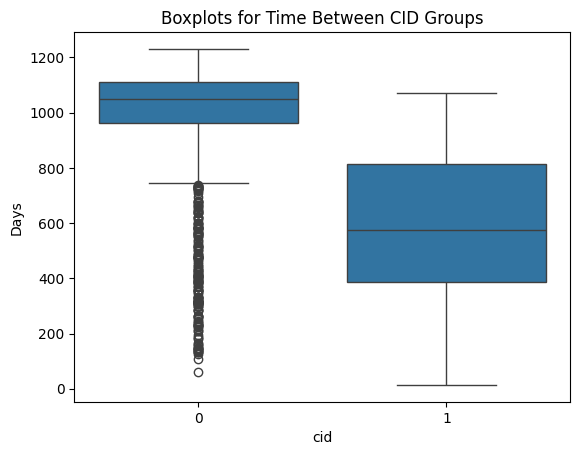

In [135]:
fig, ax = plt.subplots()
sns.boxplot(x = y, y = X.time, ax = ax)
ax.set(ylabel = "Days", title = "Boxplots for Time Between CID Groups")

Furthermore, the density plots show that the age tends to be more symmetric for the failure group with a lot of variance and time for failure being very spread apart. Meanwhile, the density plot for the censored group is heavily skewed left and heavily concentrated on the right end where a lot of the patients spent a lot of days event free. It also shows a lack of variance compared to the very spread apart failure curve.

[Text(0.5, 1.0, 'Density Plots for Time Between CID Groups')]

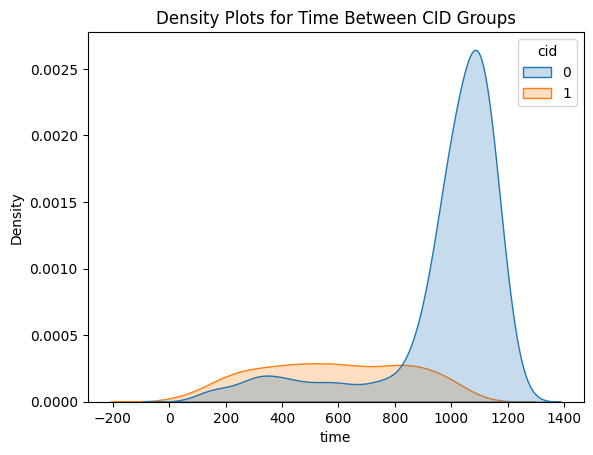

In [77]:
fig, ax = plt.subplots()
sns.kdeplot(x = X.time, hue = y, fill = True)
ax.set(title = "Density Plots for Time Between CID Groups")

Next, we'll look at the relationship between numerical variables to check for multicollinearity. It seems that the numerical variables are largely uncorrelated with each other with a couple exceptions. CD40 and CD420 alongside CD80 and CD820 are fairly correlated with one another and it's no surprise because the CD_0 and CD_20 indicates measurements taken before and after the study. Hence, it might be a good idea to drop one of the variables. Since it's harder to collect data requiring 20+ weeks, we'll focus on CD40 and CD80 as it's less costly to collect.

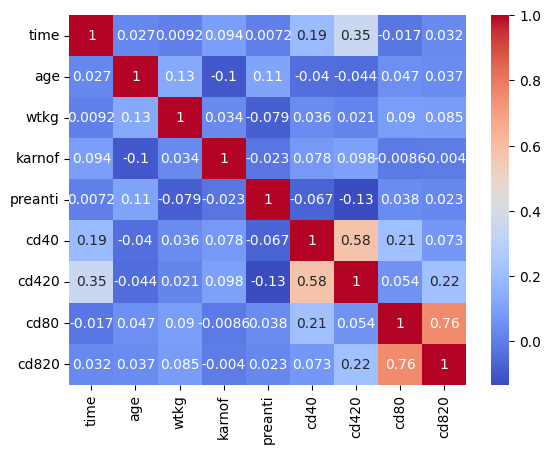

[Text(0.5, 1.0, 'Correlation Heatmap for Numerical Variables')]

In [78]:
num_var = X[['time','age','wtkg','karnof','preanti','cd40','cd420','cd80','cd820']]
fig, ax = plt.subplots()
sns.heatmap(num_var.corr(), ax = ax, cmap = 'coolwarm', annot=True)
plt.show()

# Pre-Processing

As a recap, we're going to drop str2 and treat for redundancy, zprior for only having one category, and CD420+CD820 for multicollinearity issues. We want the data to be as sparse as possible and prevent overfitting. Furthermore, we'll use get_dummies or one-hot encoding for the trt variable as it was improperly coded as an integer instead of a categorical variable.

To address, the class imbalance, we'll create synthetic data from the minority failure class using SMOTE from sci-kit learn until there are equal observations in both classes to prevent the models from classifying everything as 0/censored.

After all this, we must prepare a training-test split which was 80-20 respectively. We also stratified the response variable cid to make sure the number of failures equaled the number of censored in our split. Furthermore, 5 folds were used as a validation set to tune hyperparameters.




In [3]:
X = X.drop(columns = ['str2','treat','zprior','cd420','cd820'])
X = pd.get_dummies(X, columns = ['trt'])

# $L_1$ Logistic Regression

Since this is a binary classification problem, logistic regression is a candidate model. Furthermore, since we are interested in preventing overfitting and finding important predictors, we chose an $L_1$ pentalty to address those problems as it will zero out unimportant predictors. The way this model works is that we will select the coefficients that minimize the negative likelihood alongside the $L_1$ norm of those coefficients. Because of the $L_1$ norm, it creates a penalty for fitting more terms and might result in some zero coefficients. Similar to classic logistic regression, we'll use the coefficients to calculate a probability ($p$) and classify those with a $p>0.5$ as class 1/Failure. 

In [5]:
X_log = X.drop(columns = ['trt_0']) #Must drop one of the dummies for trt to prevent multicollinearity
X_train, X_test, y_train, y_test = train_test_split(X_log, y, test_size=0.2, stratify=y ,random_state=123)

In [6]:
model = LogisticRegression(penalty = None, solver = "newton-cg")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(model.coef_)

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       324
           1       0.83      0.61      0.70       104

    accuracy                           0.87       428
   macro avg       0.86      0.78      0.81       428
weighted avg       0.87      0.87      0.87       428

[[-6.51587147e-03  1.36864918e-02  4.72648167e-03 -5.09886961e-01
  -2.86072618e-02 -5.09726693e-01 -2.78598501e-02 -8.64721183e-02
   4.87057145e-01  4.44983538e-04 -4.73923334e-01  1.64228685e-01
   3.02210003e-02  5.54286051e-01 -1.94947490e+00 -2.22347656e-03
   3.35729375e-04 -3.38020038e-01 -6.15786480e-02 -2.30843298e-01]]


To illustrate the issues of imbalanced data, let's fit a logistic regression on our imbalanced data. As you can see, the model has no issues classifying the majority class 0/censored with a TNR of 96% but does poorly at classifying the minority class 1/failure with a TPR of 61%. It seems as if the model is simply classifying everything as 0 which will clearly create a lot of errors. To remedy this, we will create synthetic data to balance the data as stated earlier with SMOTE.

As a baseline, we will begin with a plain logistic regression with no penalty. Its accuracy is 89% and true positive rate (TPR) is 87% which isn't bad. However notice it classifies the censored class better than the failure class with a true negative rate (TNR) of 92%. Notice how this time, it does a much better job at classifying the failures (class 1) compared to the imbalanced data.

In [123]:
X_log = X.drop(columns = ['trt_0']) 
smote = SMOTE(random_state=123)
X_resampled, y_resampled = smote.fit_resample(X_log, y)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, stratify=y_resampled ,random_state=123)

In [124]:
model = LogisticRegression(penalty = None, solver = "newton-cg")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(model.coef_)

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       324
           1       0.91      0.87      0.89       324

    accuracy                           0.89       648
   macro avg       0.89      0.89      0.89       648
weighted avg       0.89      0.89      0.89       648

[[-8.14421324e-03  4.09031053e-03  6.28652310e-03 -2.11799375e+00
  -9.37735782e-01 -1.68547595e+00 -4.05287106e-02 -4.40338284e-01
   1.05875090e-01  3.03669829e-04 -1.38467588e+00  3.75093844e-01
   2.47331575e-01 -1.97489767e-01 -2.59457096e+00 -3.35477195e-03
   4.52585789e-04  9.16149773e-01  1.08126867e+00  9.85817495e-01]]


Next, we ran $L_1$ logistic regression with various penalty parameters $C = 0.01, 0.1, 1, 10, 100$ and fine tuned between the interval that had an accuracy closest to the baseline. We found the best value for C to be 0.25. Notice how it had a slightly better accuracy at 90% despite having 2 variables oprior and z30 dropped. This indicated using all variables led to some slight overfitting.

In [114]:
model = LogisticRegression(penalty = 'l1', solver = 'liblinear', C = .25)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(model.coef_)
print(X_log.columns[model.coef_.flatten() == 0])

              precision    recall  f1-score   support

           0       0.87      0.93      0.90       324
           1       0.92      0.87      0.89       324

    accuracy                           0.90       648
   macro avg       0.90      0.90      0.90       648
weighted avg       0.90      0.90      0.90       648

[[-7.50846390e-03  1.31176201e-02  1.34184653e-02 -1.46051055e+00
  -5.83665942e-01 -1.33309736e+00  8.31386821e-03  0.00000000e+00
   0.00000000e+00  2.86489151e-04 -1.20421549e+00  2.92893662e-02
   2.89443826e-01 -6.99264852e-02 -2.21866369e+00 -2.90547423e-03
   4.49167305e-04  8.05745571e-01  9.84107110e-01  8.94050810e-01]]
Index(['oprior', 'z30'], dtype='object')


Furthermore, while not the best model, we tried to see which variables would survive with a harsher penalty and thus signify importance. While a penalty of $C=0.001$ dropped the accuracy slightly to 81%, it also dropped 14 variables with time, wtkg, karnof, preanti, cd40, and cd80 surviving.

In [130]:
model = LogisticRegression(penalty = 'l1', solver = 'liblinear', C = .001)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(model.coef_)
print(X_log.columns[model.coef_.flatten() != 0])

              precision    recall  f1-score   support

           0       0.78      0.88      0.82       324
           1       0.86      0.75      0.80       324

    accuracy                           0.81       648
   macro avg       0.82      0.81      0.81       648
weighted avg       0.82      0.81      0.81       648

[[-0.00501728  0.          0.01129548  0.          0.          0.
   0.02994605  0.          0.          0.00089409  0.          0.
   0.          0.          0.         -0.00155261  0.00045609  0.
   0.          0.        ]]
Index(['time', 'wtkg', 'karnof', 'preanti', 'cd40', 'cd80'], dtype='object')


# Random Forest

The next model that can help us determine variable importance is random forest. As a summary of random forest, we'll create a bunch of decision trees and split on a different subset of variables every time. Finally the trees take a majority vote to classifty to observations. Because of the difference in trees, the model tends to generalize better and not fit specifically to the data. 

Furthermore, Random forest can calculate feature importance and thus help us determine some important variables. This will come in handy to help us answer our questions. Since random forest has a lot of hyperparameters such as number of trees, tree depth, and variables searched, we will use a grid search to tune the hyperparameters. As convention, we'll try the square root of the number of features and search values around there to determine the max number of features. Then we'll use some common numbers for the number of trees and max depth when fitting random forest.

In [84]:
smote = SMOTE(random_state=123)
X_resampled, y_resampled = smote.fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, stratify=y_resampled ,random_state=123)

In [85]:
model = RandomForestClassifier()
param_grid = { "max_features": [3, 4, 5, 6],
    "n_estimators": [100, 250, 500, 1000],
    "max_depth": [None, 3, 5, 10],
}
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
print(classification_report(y_test,y_pred))

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best Parameters: {'max_depth': None, 'max_features': 3, 'n_estimators': 250}
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       324
           1       0.93      0.92      0.93       324

    accuracy                           0.93       648
   macro avg       0.93      0.93      0.93       648
weighted avg       0.93      0.93      0.93       648



From our grid search, the best hyperparameters include having no maximum tree depth, searching 3 features max, and having 250 trees. The overall accuracy of our model improved by 3% from logistic regression with the biggest improvement coming from the TPR noticeably jumping from 87% in the logistic regression to 92% in the random forest. The TNR on the other hand stayed relatively the same.

Text(0, 0.5, 'Mean decrease in impurity')

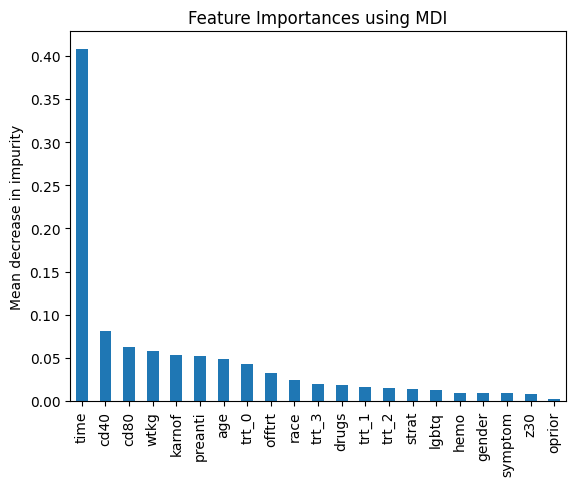

In [86]:
importances = best_rf.feature_importances_
feature_names = X_train.columns
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)
fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax)
ax.set_title("Feature Importances using MDI")
ax.set_ylabel("Mean decrease in impurity")

Based on this feature importance plot, time is the most important variable. Following behind is cd40, cd80, wtkg, karnof, preanti, and age which perfectly matches the important variables found in the logistic regression. The least important variables z30 and oprior also align perfectly with the logistic regression.

# Neural Network

Leaving feature importance for a little bit, let's focus more on predictive power. Let's not forget, one of our research questions focuses on finding the best model for predictive power. While the previous models logistic regression and random forest did very well already with 90% and 93% accuracy, let's see if a neural network, a slightly more complex model can improve upon these margins. 

The way neural networks work is that we have an input layer $x$ which we aggregate with weights $W$ ,biases $b$, and an activation function to get our hidden layer. $h = \text{ReLU}(W_1x+b_1)$. Then we'll aggregate the hidden layer with another set of weights and biases and use a sigmoid activation (since this is the convention for binary classification problems) to get a probability $p = \sigma(Wh+b)$ where we classify $p>0.5$ as class 1/Failure.

The architecture of our neural network has 22 neurons for the input layer and a single neuron with a sigmoid activation since this is binary classification. Then we'll try to determine the best number of neurons for the hidden layer with the average between the input and output and input size as common number. Then we'll try to determine the best activation function for the hidden layer and $L_2$ penalty to prevent overfitting.

In [87]:
model = MLPClassifier(max_iter=1000)
param_grid = { "hidden_layer_sizes": [5, 11, 22],
    "activation": ['relu','logistic','tanh'],
    "alpha": [0, .0001, .001, .01, .1]
}
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
best = grid_search.best_estimator_
y_pred = best.predict(X_test)
print(classification_report(y_test,y_pred))

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best Parameters: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': 5}
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       324
           1       0.89      0.86      0.87       324

    accuracy                           0.87       648
   macro avg       0.87      0.87      0.87       648
weighted avg       0.87      0.87      0.87       648



Based on our grid search, the best size for the hidden layer is 5 neurons with a ReLU activation function and an $L_2$ penalty of 0.001. The neural network seems to be our worst model yet with an 87% accuracy with the TNR and TPR being 4% and 6% lower respectively compared to random forest. This is a good example of when complex models are not always better and can be overkill. A possible explanation for this poor performance can be the neural network overfitting since it involves a lot of parameters to be estimated and tends to do better when the data is more complex and has more observations.

# Summary

As a summarization, let's compare the metrics between all the models. Based on the table and plot below, we can see that the neural network has the worst overall performance with the lowest scores across all three metrics: accuracy, TNR, and TPR. Logistic regression has the 2nd best performance with the 2nd highest accuracy at 90% but it does have a high TNR at 93%, on par with the best overall model Random Forest. Random Forest has the highest score for all 3 metrics compared to the rest of the models and thus should be selected as the final model.

In [119]:
metrics = pd.DataFrame({"Model":sorted(["Logistic Regression","Random Forest","Neural Network"]*3),
                       "Metrics":["TPR","TNR","Accuracy"]*3,
                       "Value":[.87,.93,.9,.86,.89,.87,.92,.93,.93]})
metrics.pivot_table("Value",index = "Model", columns="Metrics")

Metrics,Accuracy,TNR,TPR
Model,,,
Logistic Regression,0.90,0.93,0.87
Neural Network,0.87,0.89,0.86
Random Forest,0.93,0.93,0.92


[Text(0.5, 1.0, 'Comparison of Metrics Across All Models')]

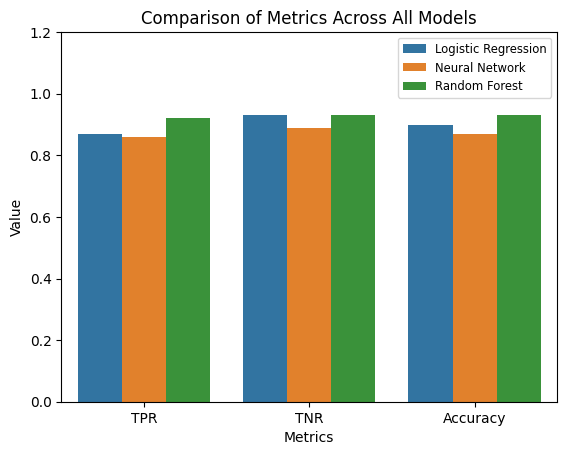

In [120]:
fig, ax = plt.subplots()
sns.barplot(data = metrics, x = "Metrics", y="Value", hue ="Model", ax=ax)
plt.legend(fontsize='small')
plt.ylim(0,1.2)
ax.set(title = "Comparison of Metrics Across All Models")

# Conclusion

To recap everything we did, we double checked our data for cleanliness. While the documentation was correct in that there were no missing values, some of the categorical variables were not encoded correctly which we had to do ourselves. Furthermore, EDA revealed some redundacy in our variables which were subsequently dropped. EDA also revealed another challenge that wasn't addressed immediately. While fitting some of the models, the performance was poor due to the major imbalance in our data. The models kept predicting everything as 0, the majority class. To address this, SMOTE was used to create synethetic data for the minority class. 

Once the data was completely cleaned, $L_1$ logistic regression and random forest were chosen as some candidate models due to having the ability to determine feature importance which was one of our questions. We also wanted a model that had predictive power which was why we also considered a neural network. To circle back to our questions, logistic regression and random forest revealed the most important predictors for treatment success. It was time with the greatest importance while cd40, cd80, wtkg, karnof, and preanti followed behind. All these variables were considered important due to logistic regression not zeroing out these variables' coefficients and random forest having high feature importance values for these variables. They also agreed that z30 and oprior were the least important variables. As for the best model for predicting HIV treatment failure in terms of metrics, random forest had the highest scores for all three metrics. It had the highest accuracy at 93%, TPR at 92%, and TNR at 93%. Random forest fits the data pretty well considering the accuracy is almost perfect and near 100%. I would be confident in the predictions our random forest makes.